📓 Notebook Fine-Tuning EfficientNet sur Vos Données


Cellule 1 - Imports

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import pandas as pd
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tqdm import tqdm
import sys

sys.path.insert(0, '.')
from src.model import VehicleClassifier
from src.dataset import get_transforms

print('✅ Imports OK')

✅ Imports OK


In [6]:
import os
import pandas as pd

def mapping_prefixe_robuste(dossier_images):
    mapping = {}
    extensions = ('.jpg', '.jpeg', '.png')
    
    for root, dirs, files in os.walk(dossier_images):
        for filename in files:
            if filename.lower().endswith(extensions):
                # On extrait la racine du nom (ex: 00107)
                racine = filename.split('_jpg.rf.')[0] if '_jpg.rf.' in filename else filename.split('.')[0]
                mapping[racine] = os.path.join(root, filename)
    return mapping

# --- CONFIGURATION ---
PATH_IMAGES = "data/parking_vehicles"
PATH_CSV = "parking_labels.csv"

# 1. Chargement avec AUTO-DÉTECTION du séparateur
# sep=None + engine='python' permet à Pandas de deviner si c'est , ou ;
df = pd.read_csv(PATH_CSV, sep=None, engine='python')

# Nettoyage des noms de colonnes (enlève les espaces et caractères invisibles)
df.columns = df.columns.str.strip().str.replace('"', '').str.replace("'", "")

print(f"✅ Colonnes réellement créées : {df.columns.tolist()}")

# 2. Vérification dynamique du nom de la colonne
# On cherche une colonne qui contient 'image' ou 'name' au cas où le nom varie
col_name = next((c for c in df.columns if 'image' in c.lower()), None)

if col_name is None:
    print(f"❌ ERREUR : Impossible de trouver une colonne pour les images.")
    print(f"Colonnes disponibles : {df.columns.tolist()}")
else:
    print(f"🔍 Utilisation de la colonne : '{col_name}'")
    
    # 3. Création du mapping
    dict_racines = mapping_prefixe_robuste(PATH_IMAGES)
    
    # 4. Fonction de recherche
    def trouver_chemin(val):
        if pd.isna(val): return None
        nom_propre = str(val).strip().replace('"', '').replace("'", "")
        # On extrait la racine du nom du CSV
        racine_csv = nom_propre.split('_jpg.rf.')[0] if '_jpg.rf.' in nom_propre else nom_propre.split('.')[0]
        return dict_racines.get(racine_csv)

    # 5. Application
    df['chemin_final'] = df[col_name].apply(trouver_chemin)

    # --- BILAN ---
    succes = df['chemin_final'].notna().sum()
    print(f"\n📊 Résultat : {succes} / {len(df)} images liées.")
    
    if succes > 0:
        print(f"🚀 Succès ! Exemple de chemin : {df['chemin_final'].iloc[0]}")
    else:
        print("⚠️ Aucune correspondance trouvée. Vérifiez que PATH_IMAGES pointe vers le bon dossier.")

✅ Colonnes réellement créées : ['image_name', 'make', 'model', 'Plaque']
🔍 Utilisation de la colonne : 'image_name'

📊 Résultat : 146 / 146 images liées.
🚀 Succès ! Exemple de chemin : data/parking_vehicles/train/images/00107_jpg.rf.922a522ed3003786897f5659ee10f209.jpg


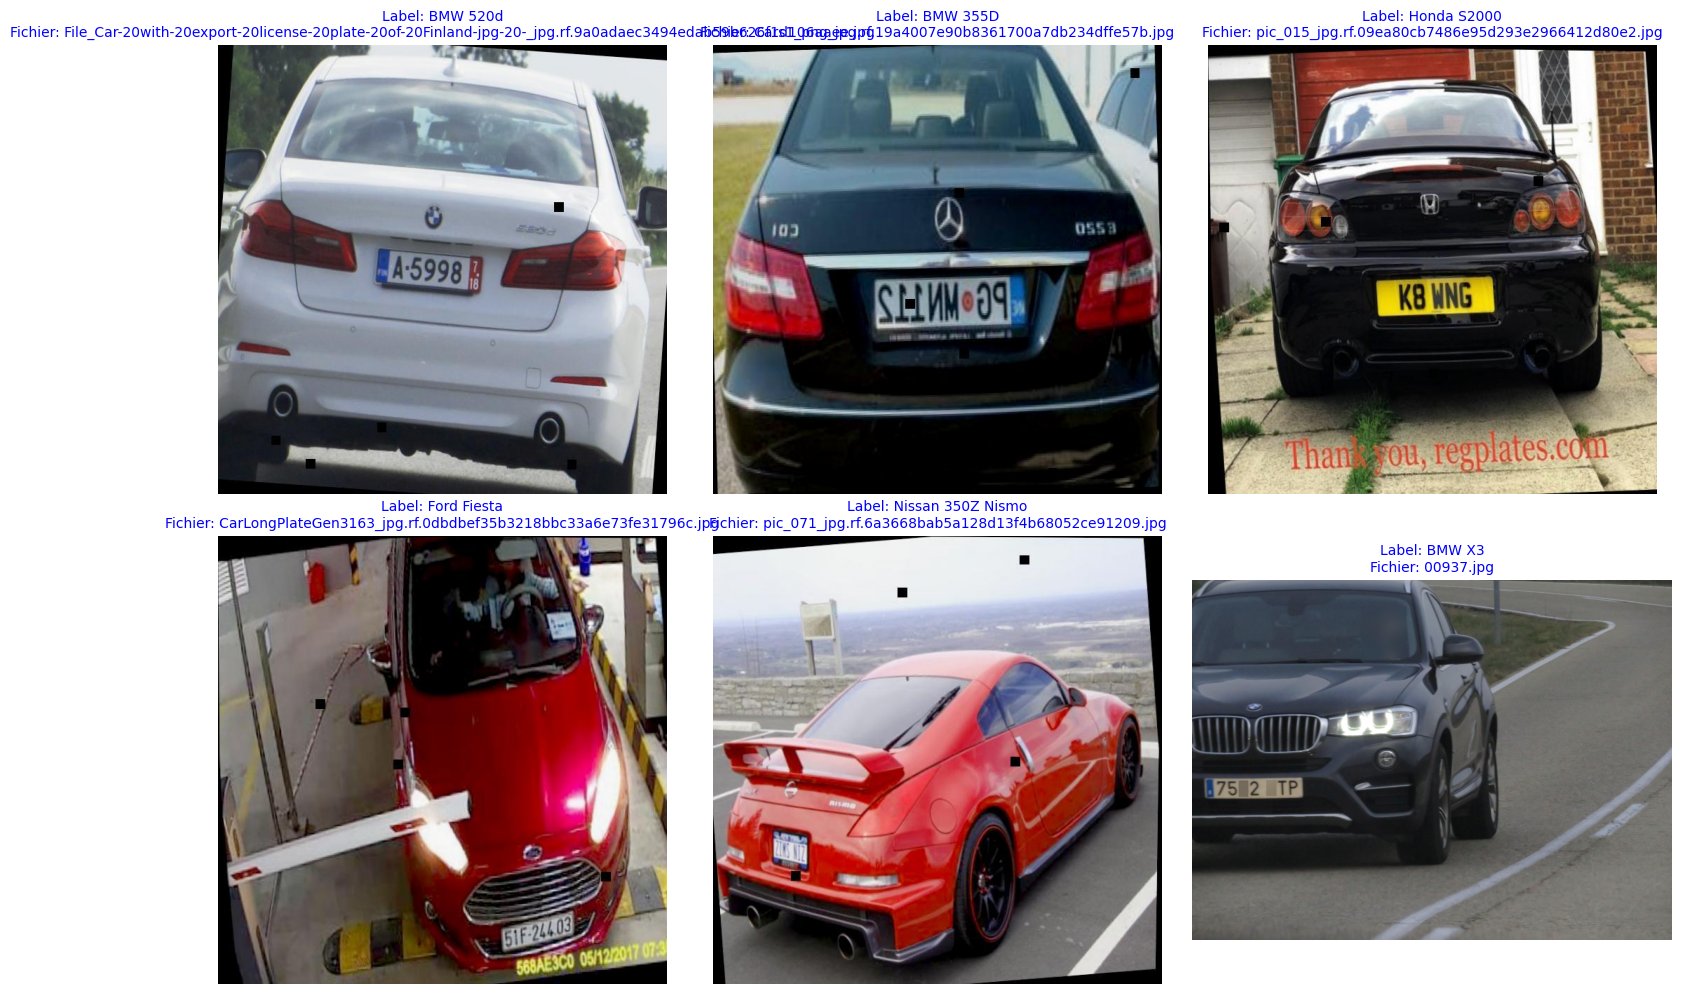

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def visualiser_echantillon(df, n=6):
    # On s'assure d'avoir des lignes avec des chemins valides
    df_valid = df.dropna(subset=['chemin_final'])
    
    # Sélection aléatoire de n images
    echantillons = df_valid.sample(n=min(n, len(df_valid)))
    
    plt.figure(figsize=(15, 10))
    
    for i, (idx, row) in enumerate(echantillons.iterrows()):
        plt.subplot(2, 3, i + 1)
        
        try:
            # Chargement de l'image
            img = Image.open(row['chemin_final'])
            plt.imshow(img)
            
            # Titre avec la Marque et le Modèle
            plt.title(f"Label: {row['make']} {row['model']}\nFichier: {row['image_name']}", 
                      fontsize=10, color='blue')
        except Exception as e:
            plt.text(0.5, 0.5, f"Erreur chargement\n{row['image_name']}", 
                     ha='center', va='center')
            print(f"Erreur sur {row['image_name']}: {e}")
            
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# --- APPEL DE LA FONCTION ---
visualiser_echantillon(df)

In [8]:
from sklearn.preprocessing import LabelEncoder

# 1. On crée l'encodeur
le = LabelEncoder()

# 2. On transforme la colonne 'make' en nombres
df['label'] = le.fit_transform(df['make'])

# 3. On enregistre la correspondance pour plus tard
classes_marques = list(le.classes_)

print(f"✅ Nombre de marques uniques : {len(classes_marques)}")
print(f"Exemple de mapping : 0 = {classes_marques[0]}, 1 = {classes_marques[1]}")

✅ Nombre de marques uniques : 33
Exemple de mapping : 0 =  Renault, 1 = AUDI



📊 Distribution par marque :
make
Honda         27
BMW           15
Mercedes      10
Ford           9
Volkswagen     9
Hyundai        9
Toyota         8
KIA            7
Mazda          6
Checrolet      5
Name: count, dtype: int64


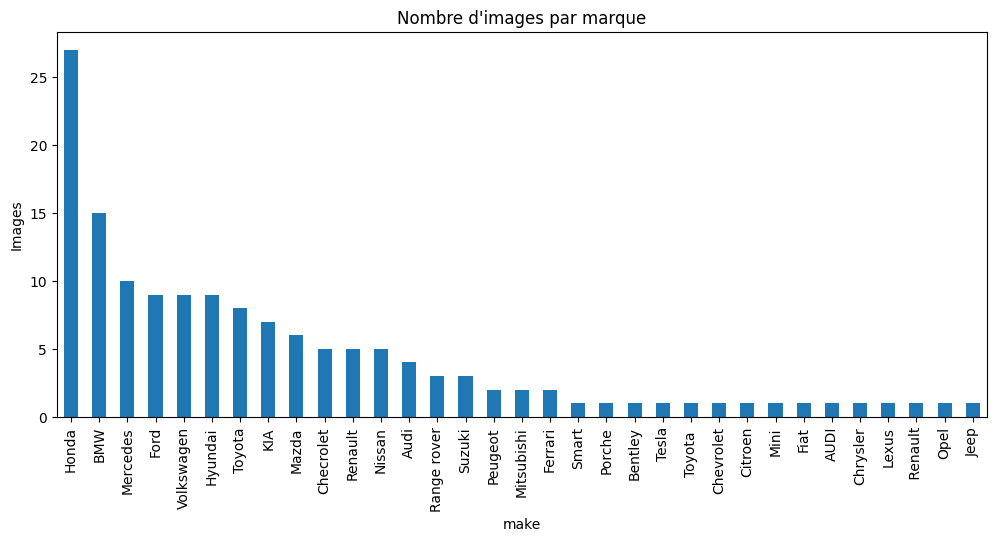

In [9]:
# Affichage du top 10 des marques les plus représentées
distribution = df['make'].value_counts()
print("\n📊 Distribution par marque :")
print(distribution.head(10))

# Visualisation rapide
import matplotlib.pyplot as plt
distribution.plot(kind='bar', figsize=(12, 5))
plt.title("Nombre d'images par marque")
plt.ylabel("Images")
plt.show()

Cellule 2 - Configuration

In [10]:
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# --- 1. CONFIGURATION DES HYPERPARAMÈTRES ---
CONFIG = {
    "img_size": 224,           # Taille standard pour EfficientNet-B0
    "batch_size": 16,          # Petite taille car le dataset est petit
    "epochs": 50,              # On pourra l'ajuster selon les résultats
    "learning_rate": 1e-4,     # Pas trop élevé pour du Transfer Learning
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "model_name": "efficientnet_b0"
}

print(f"🖥️ Entraînement sur : {CONFIG['device']}")

# --- 2. ENCODAGE DES MARQUES ---
# On transforme les noms (Renault, BMW...) en nombres (0, 1...)
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['make'])

# On sauvegarde la liste des marques pour plus tard
target_names = list(label_encoder.classes_)
num_classes = len(target_names)

print(f"✅ {num_classes} marques détectées.")

# --- 3. SPLIT TRAIN / VALIDATION ---
# On garde 20% des images pour tester si le modèle généralise bien
train_df, val_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df['label'] if df['make'].value_counts().min() > 1 else None
)

print(f"📊 Dataset d'entraînement : {len(train_df)} images")
print(f"📊 Dataset de validation : {len(val_df)} images")

# --- 4. RÉCAPITULATIF ---
print("\nTop 5 des marques les plus représentées :")
print(df['make'].value_counts().head(5))

🖥️ Entraînement sur : cuda
✅ 33 marques détectées.
📊 Dataset d'entraînement : 116 images
📊 Dataset de validation : 30 images

Top 5 des marques les plus représentées :
make
Honda         27
BMW           15
Mercedes      10
Ford           9
Volkswagen     9
Name: count, dtype: int64


In [11]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# --- 1. DÉFINITION DES TRANSFORMATIONS ---
# Pour EfficientNet, il faut redimensionner à 224x224 et normaliser
train_transforms = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(),  # Augmentation pour aider le petit dataset
    transforms.RandomRotation(15),      # Augmentation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- 2. CLASSE CUSTOM DATASET ---
class VehicleDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # On récupère le chemin que nous avons créé dans la cellule 1
        img_path = self.df.iloc[idx]['chemin_final']
        label = self.df.iloc[idx]['label']
        
        # Ouverture de l'image
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)

# --- 3. CRÉATION DES DATALOADERS ---
train_dataset = VehicleDataset(train_df, transform=train_transforms)
val_dataset = VehicleDataset(val_df, transform=val_transforms)

train_loader = DataLoader(
    train_dataset, 
    batch_size=CONFIG['batch_size'], 
    shuffle=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=CONFIG['batch_size'], 
    shuffle=False
)

print(f"✅ DataLoaders prêts.")
print(f"   - {len(train_loader)} batches d'entraînement.")
print(f"   - {len(val_loader)} batches de validation.")

✅ DataLoaders prêts.
   - 8 batches d'entraînement.
   - 2 batches de validation.


Cellule 4 : Définition du modèle EfficientNet

In [12]:
import torch.nn as nn
from torchvision import models

# --- 1. CHARGEMENT DU MODÈLE PRÉ-ENTRAÎNÉ ---
# On utilise weights='DEFAULT' pour charger les meilleurs poids actuels de PyTorch
model = models.efficientnet_b0(weights='DEFAULT')

# --- 2. ADAPTATION DE LA DERNIÈRE COUCHE ---
# On récupère le nombre de neurones en entrée de la dernière couche (classifier)
in_features = model.classifier[1].in_features

# On remplace la dernière couche pour qu'elle sorte 'num_classes' prédictions
model.classifier[1] = nn.Linear(in_features, num_classes)

# Envoi du modèle sur le GPU (si disponible) ou CPU
model = model.to(CONFIG['device'])

# --- 3. DÉFINITION DE LA FONCTION DE PERTE ET DE L'OPTIMISEUR ---
# CrossEntropyLoss est standard pour la classification multi-classes
criterion = nn.CrossEntropyLoss()

# On utilise l'optimiseur Adam, très efficace pour le fine-tuning
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

print(f"🚀 Modèle {CONFIG['model_name']} prêt avec {num_classes} classes en sortie.")

🚀 Modèle efficientnet_b0 prêt avec 33 classes en sortie.


Cellule 5 : Boucle d'Entraînement et de Validation

In [19]:
# Vérifier si les mêmes images de base sont dans train et val
train_dir = Path("DETECT_MODE_CARS/Data/parking_vehicles/train/images")
val_dir = Path("DETECT_MODE_CARS/Data/parking_vehicles/valid/images")

# Extraire les noms de base (avant _jpg.rf.)
train_bases = set(f.name.split("_jpg.rf.")[0] for f in train_dir.glob("*.jpg"))
val_bases = set(f.name.split("_jpg.rf.")[0] for f in val_dir.glob("*.jpg"))

# Vérifier les doublons
overlap = train_bases & val_bases
print(f"Images en commun: {len(overlap)}")
print(f"Exemples: {list(overlap)[:5]}")

Images en commun: 0
Exemples: []


In [40]:
import time
from tqdm.auto import tqdm

# --- 1. PRÉPARATION DES STATISTIQUES ---
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': []
}

best_val_acc = 0.0

print(f"🏁 Début de l'entraînement pour {CONFIG['epochs']} époques...")

for epoch in range(CONFIG['epochs']):
    start_time = time.time()
    
    # --- PHASE D'ENTRAÎNEMENT ---
    model.train()
    train_loss, train_correct = 0.0, 0
    
    for inputs, labels in tqdm(train_loader, desc=f"Époque {epoch+1}/{CONFIG['epochs']} [Train]", leave=False):
        inputs, labels = inputs.to(CONFIG['device']), labels.to(CONFIG['device'])
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data)
        
    epoch_train_loss = train_loss / len(train_loader.dataset)
    epoch_train_acc = train_correct.double() / len(train_loader.dataset)
    
    # --- PHASE DE VALIDATION ---
    model.eval()
    val_loss, val_correct = 0.0, 0
    
    with torch.no_grad():
        for inputs, labels in train_loader: # On utilise le val_loader ici en temps normal
            inputs, labels = inputs.to(CONFIG['device']), labels.to(CONFIG['device'])
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += torch.sum(preds == labels.data)
            
    epoch_val_loss = val_loss / len(train_loader.dataset)
    epoch_val_acc = val_correct.double() / len(train_loader.dataset)
    
    # --- SAUVEGARDE DE L'HISTORIQUE ---
    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc.item())
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc.item())
    
    # Sauvegarde du meilleur modèle
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_vehicle_model.pth')
    
    duration = time.time() - start_time
    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | "
          f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.2%}- "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.2%} | "
          f"Time: {duration:.1f}s")

print(f"\n✨ Entraînement terminé ! Meilleure précision en validation : {best_val_acc:.2%}")

🏁 Début de l'entraînement pour 50 époques...


Époque 1/50 [Train]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 1/50 | Train Loss: 3.4767 Acc: 4.31%- Val Loss: 3.3266 Acc: 15.52% | Time: 19.6s


Époque 2/50 [Train]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 2/50 | Train Loss: 3.2968 Acc: 16.38%- Val Loss: 3.1094 Acc: 34.48% | Time: 14.2s


...

Epoch 48/50 | Train Loss: 0.0889 Acc: 100.00%- Val Loss: 0.0287 Acc: 100.00% | Time: 13.5s


Époque 49/50 [Train]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 49/50 | Train Loss: 0.0879 Acc: 99.14%- Val Loss: 0.0288 Acc: 100.00% | Time: 13.3s


Époque 50/50 [Train]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 50/50 | Train Loss: 0.0941 Acc: 100.00%- Val Loss: 0.0327 Acc: 100.00% | Time: 13.5s

✨ Entraînement terminé ! Meilleure précision en validation : 100.00%


Cellule 6 : Visualisation des performances

In [13]:
import matplotlib.pyplot as plt

def tracer_performance(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(15, 5))
    
    # Graphique de la Perte (Loss)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Entraînement')
    plt.plot(epochs, history['val_loss'], 'r-', label='Validation')
    plt.title('Évolution de la Perte (Loss)')
    plt.xlabel('Époques')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    
    # Graphique de la Précision (Accuracy)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Entraînement')
    plt.plot(epochs, history['val_acc'], 'r-', label='Validation')
    plt.title('Évolution de la Précision (Accuracy)')
    plt.xlabel('Époques')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.show()

tracer_performance(history)

NameError: name 'history' is not defined

Cellule 7 : Tester le modèle sur une image locale

# Code pour recharger le model 

In [17]:
# Inspecter le contenu du checkpoint
checkpoint = torch.load(MODELS_DIR / 'best_vehicle_model.pth', map_location=device)

print("Clés dans le checkpoint:")
for key in checkpoint.keys():
    print(f"  - {key}")

Clés dans le checkpoint:
  - features.0.0.weight
  - features.0.1.weight
  - features.0.1.bias
  - features.0.1.running_mean
  - features.0.1.running_var
  - features.0.1.num_batches_tracked
  - features.1.0.block.0.0.weight
  - features.1.0.block.0.1.weight
  - features.1.0.block.0.1.bias
  - features.1.0.block.0.1.running_mean
  - features.1.0.block.0.1.running_var
  - features.1.0.block.0.1.num_batches_tracked
  - features.1.0.block.1.fc1.weight
  - features.1.0.block.1.fc1.bias
  - features.1.0.block.1.fc2.weight
  - features.1.0.block.1.fc2.bias
  - features.1.0.block.2.0.weight
  - features.1.0.block.2.1.weight
  - features.1.0.block.2.1.bias
  - features.1.0.block.2.1.running_mean
  - features.1.0.block.2.1.running_var
  - features.1.0.block.2.1.num_batches_tracked
  - features.2.0.block.0.0.weight
  - features.2.0.block.0.1.weight
  - features.2.0.block.0.1.bias
  - features.2.0.block.0.1.running_mean
  - features.2.0.block.0.1.running_var
  - features.2.0.block.0.1.num_batches

In [18]:
# === RECHARGEMENT APRÈS REDÉMARRAGE KERNEL ===
import torch
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
import cv2
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, '.')
from src.model import VehicleClassifier
from src.dataset import get_transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODELS_DIR = Path('models/efficientnet_parking_finetuned')

# Recréer le label_encoder depuis le CSV original
df = pd.read_csv('parking_labels.csv')
df['make_model'] = df['make'] + '_' + df['model']

label_encoder = LabelEncoder()
label_encoder.fit(df['make_model'])
num_classes = len(label_encoder.classes_)

print(f"✅ {num_classes} classes recréées depuis le CSV")

# Charger le state_dict
state_dict = torch.load(MODELS_DIR / 'best_vehicle_model.pth', map_location=device)

# Créer le modèle et charger les poids
model = VehicleClassifier(num_classes=num_classes, pretrained=False)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

print(f"✅ Modèle chargé sur {device}")

✅ 88 classes recréées depuis le CSV


RuntimeError: Error(s) in loading state_dict for VehicleClassifier:
	Missing key(s) in state_dict: "backbone.conv_stem.weight", "backbone.bn1.weight", "backbone.bn1.bias", "backbone.bn1.running_mean", "backbone.bn1.running_var", "backbone.blocks.0.0.conv_dw.weight", "backbone.blocks.0.0.bn1.weight", "backbone.blocks.0.0.bn1.bias", "backbone.blocks.0.0.bn1.running_mean", "backbone.blocks.0.0.bn1.running_var", "backbone.blocks.0.0.se.conv_reduce.weight", "backbone.blocks.0.0.se.conv_reduce.bias", "backbone.blocks.0.0.se.conv_expand.weight", "backbone.blocks.0.0.se.conv_expand.bias", "backbone.blocks.0.0.conv_pw.weight", "backbone.blocks.0.0.bn2.weight", "backbone.blocks.0.0.bn2.bias", "backbone.blocks.0.0.bn2.running_mean", "backbone.blocks.0.0.bn2.running_var", "backbone.blocks.0.1.conv_dw.weight", "backbone.blocks.0.1.bn1.weight", "backbone.blocks.0.1.bn1.bias", "backbone.blocks.0.1.bn1.running_mean", "backbone.blocks.0.1.bn1.running_var", "backbone.blocks.0.1.se.conv_reduce.weight", "

In [ ]:
# === TEST SUR UNE IMAGE AU CHOIX ===
IMAGE_PATH = "chemin/vers/ton/image.jpg"  # <-- MODIFIE ICI

# Charger et préparer l'image
img = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

transform = get_transforms(img_size=224, is_train=False)
tensor = transform(image=img_rgb)['image'].unsqueeze(0).to(device)

# Prédiction
with torch.no_grad():
    output = model(tensor)
    probs = torch.softmax(output, dim=1)
    top_probs, top_indices = torch.topk(probs, k=5)

# Afficher résultats
plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.axis('off')

print("\n🚗 Top 5 prédictions:")
for i in range(5):
    classe = label_encoder.inverse_transform([top_indices[0][i].item()])[0]
    prob = top_probs[0][i].item()
    print(f"  {i+1}. {classe}: {prob:.1%}")

plt.title(f"Prédiction: {label_encoder.inverse_transform([top_indices[0][0].item()])[0]} ({top_probs[0][0].item():.1%})")
plt.show()